In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv")

# Target variable
df["High_Performance"] = (df["Revenue_Generated"] > df["Revenue_Generated"].median()).astype(int)

# Clean data
df = df.drop(columns=[
    "Campaign_ID","Product_ID","Customer_ID",
    "Bundle_ID","Common_Keywords"
], errors='ignore')

df = df.dropna()

# Encode categorical
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

# Split
X = df.drop("High_Performance", axis=1)
y = df["High_Performance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


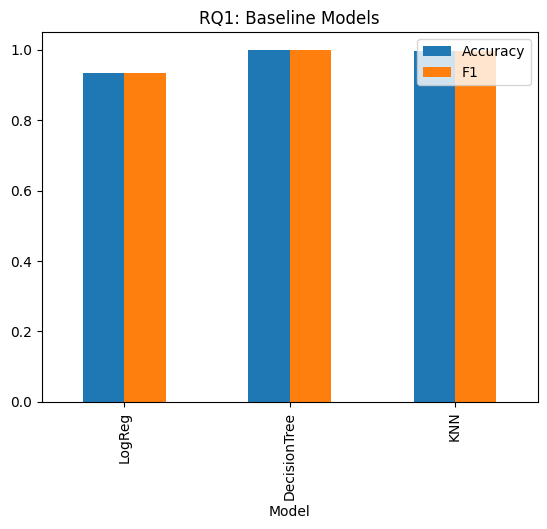

In [2]:
models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds, average='weighted'),
        recall_score(y_test, preds, average='weighted'),
        f1_score(y_test, preds, average='weighted')
    ])

df_rq1 = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
df_rq1.to_csv("/kaggle/working/RQ1_table.csv", index=False)

df_rq1.set_index("Model")[["Accuracy","F1"]].plot(kind="bar")
plt.title("RQ1: Baseline Models")
plt.savefig("/kaggle/working/RQ1_figure.pdf")
plt.show()